# Métodos de Ensemble

**Francisco Aparecido Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Um **ensemble** (comitê, conjunto) combina as predições de **vários modelos** para obter uma predição final, geralmente mais precisa e mais estável do que a de qualquer modelo individual. A ideia lembra a "sabedoria das multidões": se vários especialistas, cada um com uma visão parcial e imperfeita do problema, votarem, o resultado agregado tende a ser melhor do que o de um único especialista, desde que os erros dos especialistas não sejam todos iguais (isto é, desde que haja alguma diversidade entre eles).


Formalmente, lembrando a decomposição do erro em viés e variância:
$$
\text{Erro} = \text{Viés}^2 + \text{Variância} + \text{erro irredutível},
$$
cada família de métodos de ensemble ataca um lado diferente desse compromisso:

- **Bagging** (*Bootstrap Aggregating*): treina vários modelos **em paralelo, de forma independente**, cada um em uma amostra bootstrap diferente dos dados, e combina as predições por votação/média. Reduz principalmente a **variância**. É mais eficaz quando o modelo base é instável (alta variância), como uma árvore de decisão profunda.
- **Boosting**: treina vários modelos **em sequência**, cada um focando em **corrigir os erros do anterior** (dando mais peso às observações difíceis de classificar). Reduz principalmente o **viés**, combinando muitos modelos simples ("aprendizes fracos") para formar um modelo final flexível.
- **Random Forest**: uma variação do bagging aplicada especificamente a árvores de decisão, que adiciona uma segunda fonte de aleatoriedade (um subconjunto aleatório de atributos em cada divisão da árvore) para tornar as árvores ainda menos correlacionadas entre si, aumentando a redução de variância.

## 1 — Dados artificiais

Nesta parte, geramos os dados, de forma a poder visualizar a fronteira de decisão dos modelos em 2D, e poder conferir se a Random Forest identifica corretamente quais atributos são realmente informativos (porque, ao gerar os dados, sabemos exatamente quais são).

Vamos gerar dois conjuntos de dados artificiais:

1. **Dados 2D** (`make_moons`), usados apenas para **visualizar** a fronteira de decisão de cada método;
2. **Dados de maior dimensão** (`make_classification`), com um número controlado de atributos realmente informativos e de atributos que são apenas ruído, usados para avaliar os modelos quantitativamente (acurácia, AUC) e verificar se a importância de atributos da Random Forest identifica corretamente os atributos informativos.

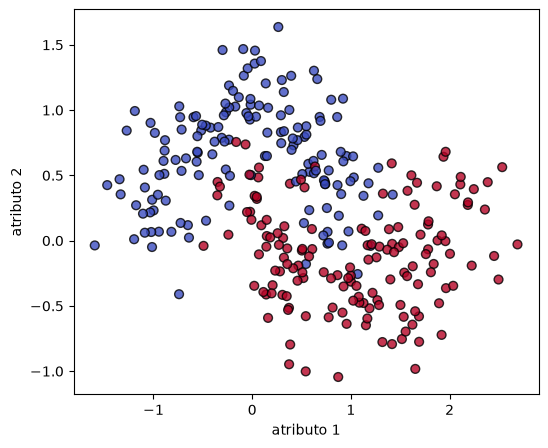

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split

# dados 2D, para visualização da fronteira de decisão
X_syn, y_syn = make_moons(n_samples=300, noise=0.25, random_state=42)
X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42, stratify=y_syn
)

plt.figure(figsize=(6, 5))
plt.scatter(X_syn[:, 0], X_syn[:, 1], c=y_syn, cmap='coolwarm', s=40, edgecolor='k', alpha=0.8)
plt.xlabel('atributo 1')
plt.ylabel('atributo 2')
plt.show()

In [ ]:
# dados de maior dimensão, para avaliação quantitativa
# 5 atributos realmente informativos + 15 atributos que são apenas ruído
n_informativos = 5
n_ruido = 15

X_art, y_art = make_classification(
    n_samples=1000,
    n_features=n_informativos + n_ruido,
    n_informative=n_informativos,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=2,
    flip_y=0.02, # um pouco de ruído nos rótulos, para não ficar trivial demais
    class_sep=1.2,
    shuffle=False, # mantém a ordem das colunas: as n_informativos primeiras são as informativas
    random_state=42,
)
feature_names_art = [f'informativo_{i+1}' for i in range(n_informativos)] + \
                    [f'ruido_{i+1}' for i in range(n_ruido)]

X_art_train, X_art_test, y_art_train, y_art_test = train_test_split(X_art, y_art,
                                                                    test_size=0.3,
                                                                    random_state=42,
                                                                    stratify=y_art)

print('Número de observações e atributos:', X_art.shape)
print('Atributos realmente informativos:', feature_names_art[:n_informativos])

Número de observações e atributos: (1000, 20)
Atributos realmente informativos: ['informativo_1', 'informativo_2', 'informativo_3', 'informativo_4', 'informativo_5']


Notem que usamos `shuffle=False` no `make_classification`. Por padrão, essa função embaralha a ordem das colunas antes de retornar os dados. Isto é irrelevante para o desempenho dos modelos (a ordem das colunas não importa para eles), mas destruiria a correspondência que estamos assumindo entre a posição da coluna e o nome do atributo (`informativo_1, ..., informativo_5, ruido_1, ...`). Com `shuffle=False`, garantimos que as `n_informativos` primeiras colunas retornadas são, de fato, as colunas informativas, o que precisamos para a conferência de importância de atributos mais adiante.

Vamos definir uma função para desenhar a fronteira de decisão de um modelo já treinado nos dados 2D.

In [10]:
# função para plotar a fronteira de decisão
def plot_decision_boundary(model, X, y, ax, title):
    """Desenha a fronteira de decisão de um classificador binário já
    treinado, sobre um grid 2D, junto com os pontos de treinamento.
    """
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=25, edgecolor='k', alpha=0.9)
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

### Bagging

**Bagging** (*Bootstrap Aggregating*): treinar vários modelos independentes em versões levemente diferentes do conjunto de treinamento, e combinar as predições.

**Algoritmo:**

1. Para $b = 1, \ldots, B$:
   - Gere uma **amostra bootstrap** $D_b$: sorteie $n$ observações do conjunto de treinamento original, **com reposição**. Em média, cada amostra bootstrap contém cerca de 63% das observações originais, deixando de fora cerca de 37% (as observações *out-of-bag*, que podem ser usadas para estimar o erro do modelo sem precisar de um conjunto de validação separado).
   - Treine um modelo $h_b$ nessa amostra $D_b$.
2. Combine as predições dos $B$ modelos: **votação majoritária** (classificação) ou **média** (regressão).

Se os $B$ modelos fossem totalmente independentes, a variância da média seria $\text{Var}(h_b)/B$. Na prática, a redução é menor (os modelos compartilham o mesmo conjunto de dados original), mas ainda assim substancial quando o modelo base é instável, como uma árvore de decisão profunda.

Vamos visualizar o efeito do bagging nos dados 2D: uma única árvore profunda (tende a overfitting) vs. um ensemble de bagging com o mesmo tipo de árvore.

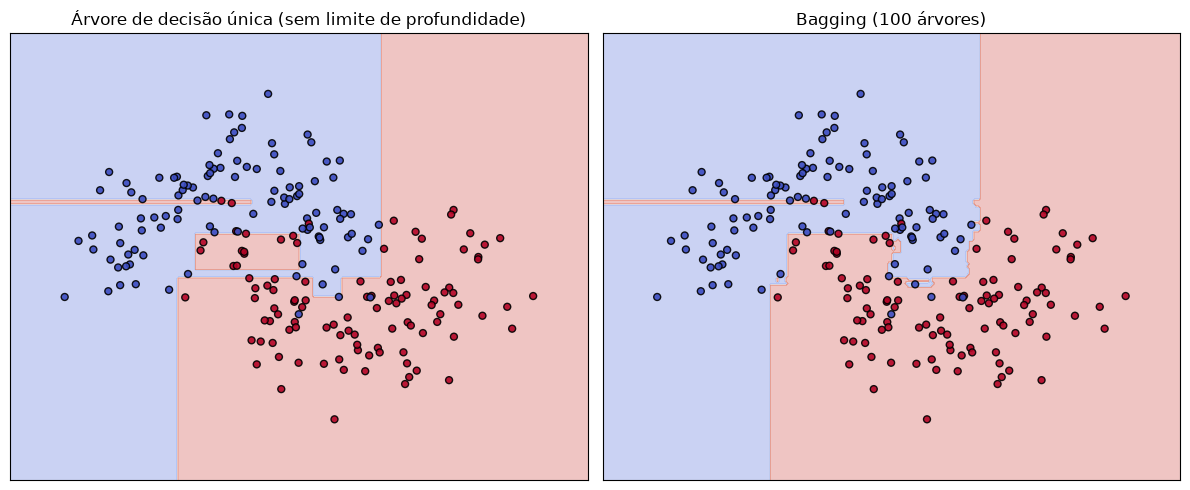

In [11]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# árvore de decisão
tree_single = DecisionTreeClassifier(random_state=42)
tree_single.fit(X_syn_train, y_syn_train)
plot_decision_boundary(tree_single, X_syn_train, y_syn_train, axes[0],
                       'Árvore de decisão única (sem limite de profundidade)')

# bagging
bagging_demo = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
)
bagging_demo.fit(X_syn_train, y_syn_train)
plot_decision_boundary(bagging_demo, X_syn_train, y_syn_train, axes[1],
                       'Bagging (100 árvores)')

plt.tight_layout()
plt.show()

Note como a fronteira da árvore única é irregular e recortada, seguindo de perto pontos isolados (ruído), o que é um sintoma de overfitting. Já a fronteira do bagging é bem mais suave: ao combinar árvores treinadas em amostras ligeiramente diferentes, os detalhes específicos de cada amostra tendem a se cancelar, enquanto o padrão geral se reforça.

Agora, avaliação quantitativa: ajustamos os hiperparâmetros do bagging com `GridSearchCV` nos dados artificiais de maior dimensão (`X_art`), usando `scoring='roc_auc'` para priorizar a AUC.

In [12]:
from sklearn.model_selection import GridSearchCV

# hiperarâmetros
param_grid_bag = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'estimator__max_depth': [3, 5, None],
}

# validação cruzada
bagging_gs = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), random_state=42),
    param_grid_bag,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)
bagging_gs.fit(X_art_train, y_art_train)

print('Melhores hiperparâmetros:', bagging_gs.best_params_)
print('Melhor AUC (validação cruzada, treino):', bagging_gs.best_score_)

Melhores hiperparâmetros: {'estimator__max_depth': 5, 'max_samples': 1.0, 'n_estimators': 100}
Melhor AUC (validação cruzada, treino): 0.974957459039954


Acurácia (teste): 0.9233333333333333
AUC (teste): 0.9824888888888889


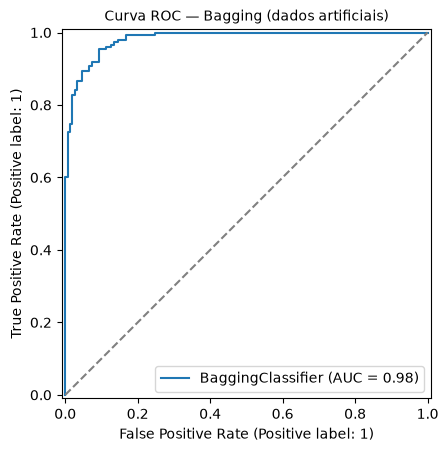

In [13]:
from sklearn.metrics import RocCurveDisplay, accuracy_score, roc_auc_score

# modelo ajustado
bagging_best = bagging_gs.best_estimator_
y_pred_bag = bagging_best.predict(X_art_test)
y_score_bag = bagging_best.predict_proba(X_art_test)[:, 1]

print('Acurácia (teste):', accuracy_score(y_art_test, y_pred_bag))
print('AUC (teste):', roc_auc_score(y_art_test, y_score_bag))

# mostra a curva ROC
RocCurveDisplay.from_estimator(bagging_best, X_art_test, y_art_test)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('Curva ROC — Bagging (dados artificiais)', fontsize = 10)
plt.show()

### Boosting (AdaBoost)

Diferente do bagging, o **boosting** treina os modelos **em sequência**: cada novo modelo dá mais atenção às observações que os modelos anteriores erraram. O algoritmo mais clássico é o **AdaBoost**.

**Algoritmo (classificação binária, $y_i \in \{-1, +1\}$):**

1. Inicialize os pesos das observações: $w_i = \dfrac{1}{n}$, $i=1,\ldots,n$.
2. Para $m = 1, \ldots, M$:
   - Treine um **aprendiz fraco** $h_m(\mathbf{x})$ (tipicamente uma árvore de profundidade 1, chamado decision stump) sobre os dados ponderados por $w_i$;
   - Erro ponderado: $\text{err}_m = \dfrac{\sum_i w_i \, \mathbb{1}(y_i \neq h_m(\mathbf{x}_i))}{\sum_i w_i}$;
   - Peso do modelo no ensemble: $\alpha_m = \dfrac{1}{2}\ln\left(\dfrac{1-\text{err}_m}{\text{err}_m}\right)$;
   - Atualize os pesos: $w_i \leftarrow w_i \cdot \exp\big(\alpha_m \, \mathbb{1}(y_i \neq h_m(\mathbf{x}_i))\big)$, e normalize.
3. Predição final: $H(\mathbf{x}) = \text{sinal}\left(\sum_{m} \alpha_m \, h_m(\mathbf{x})\right)$.

Boosting reduz principalmente o **viés**: combina muitos modelos simples em um modelo final flexível, mas pode sofrer overfitting se usado com muitas iterações e um modelo base pouco regularizado.

Visualização: um único *decision stump* vs. AdaBoost com 100 stumps.

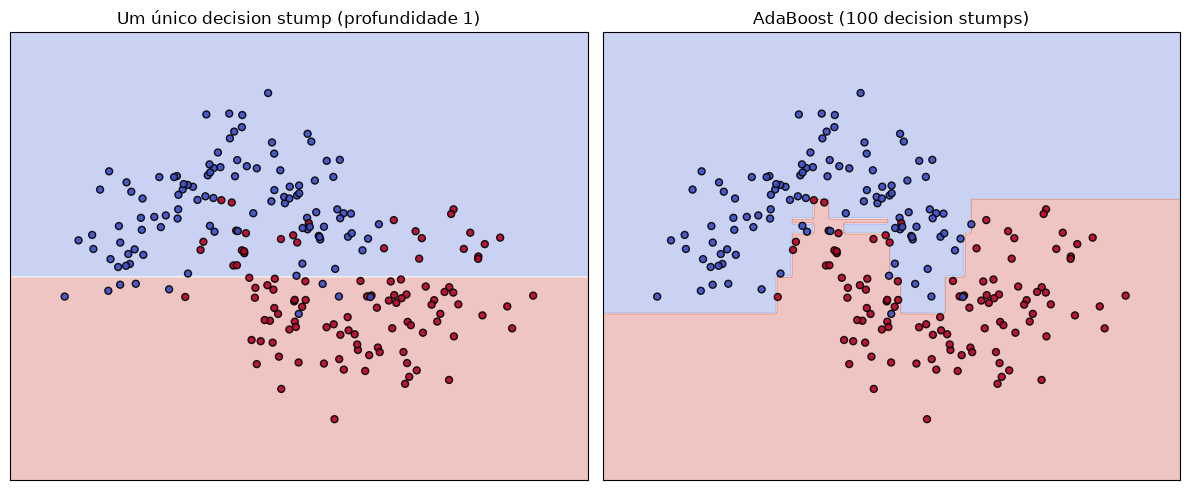

In [15]:
from sklearn.ensemble import AdaBoostClassifier

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# árvore de decisão
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X_syn_train, y_syn_train)
plot_decision_boundary(stump, X_syn_train, y_syn_train, axes[0],
                       'Um único decision stump (profundidade 1)')

# Ada Boost
ada_demo = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42,
    #algorithm='SAMME'
)
ada_demo.fit(X_syn_train, y_syn_train)
plot_decision_boundary(ada_demo, X_syn_train, y_syn_train, axes[1],
                       'AdaBoost (100 decision stumps)')

plt.tight_layout()
plt.show()

Um único stump só separa o espaço com uma reta, pois é pouco flexível para o formato de "lua". O AdaBoost, combinando 100 stumps sequencialmente e de forma ponderada, aproxima uma fronteira bem mais próxima do formato real.

Avaliação quantitativa: `GridSearchCV` para `n_estimators` e `learning_rate`, nos dados artificiais de maior dimensão.

In [16]:
# hiperarâmetros
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

# validação cruzada
ada_gs = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                       random_state=42,
                       #algorithm='SAMME'
                      ),
    param_grid_ada,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
ada_gs.fit(X_art_train, y_art_train)

print('Melhores hiperparâmetros:', ada_gs.best_params_)
print('Melhor AUC (validação cruzada, treino):', ada_gs.best_score_)

Melhores hiperparâmetros: {'learning_rate': 0.5, 'n_estimators': 200}
Melhor AUC (validação cruzada, treino): 0.9693040228951346


Acurácia (teste): 0.91
AUC (teste): 0.9612888888888889


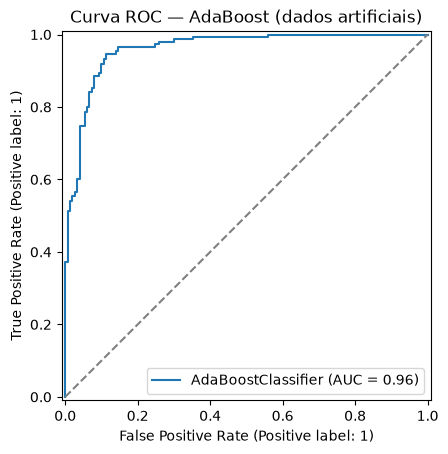

In [17]:
ada_best = ada_gs.best_estimator_
y_pred_ada = ada_best.predict(X_art_test)
y_score_ada = ada_best.predict_proba(X_art_test)[:, 1]

print('Acurácia (teste):', accuracy_score(y_art_test, y_pred_ada))
print('AUC (teste):', roc_auc_score(y_art_test, y_score_ada))

RocCurveDisplay.from_estimator(ada_best, X_art_test, y_art_test)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('Curva ROC — AdaBoost (dados artificiais)')
plt.show()

### Random Forest

A **Random Forest** é essencialmente um bagging de árvores de decisão, com um ingrediente extra: em cada divisão de cada árvore, considera-se apenas um **subconjunto aleatório dos atributos** (em vez de todos). Isso decorrelaciona as árvores, pois se houvesse um atributo muito forte, o bagging comum faria a maioria das árvores usá-lo logo na primeira divisão, tornando as árvores parecidas entre si (e reduzindo o ganho de agregá-las). Tipicamente, o número de atributos sorteados por divisão é $\sqrt{p}$ (classificação) ou $p/3$ (regressão).

Visualização das três fronteiras lado a lado:

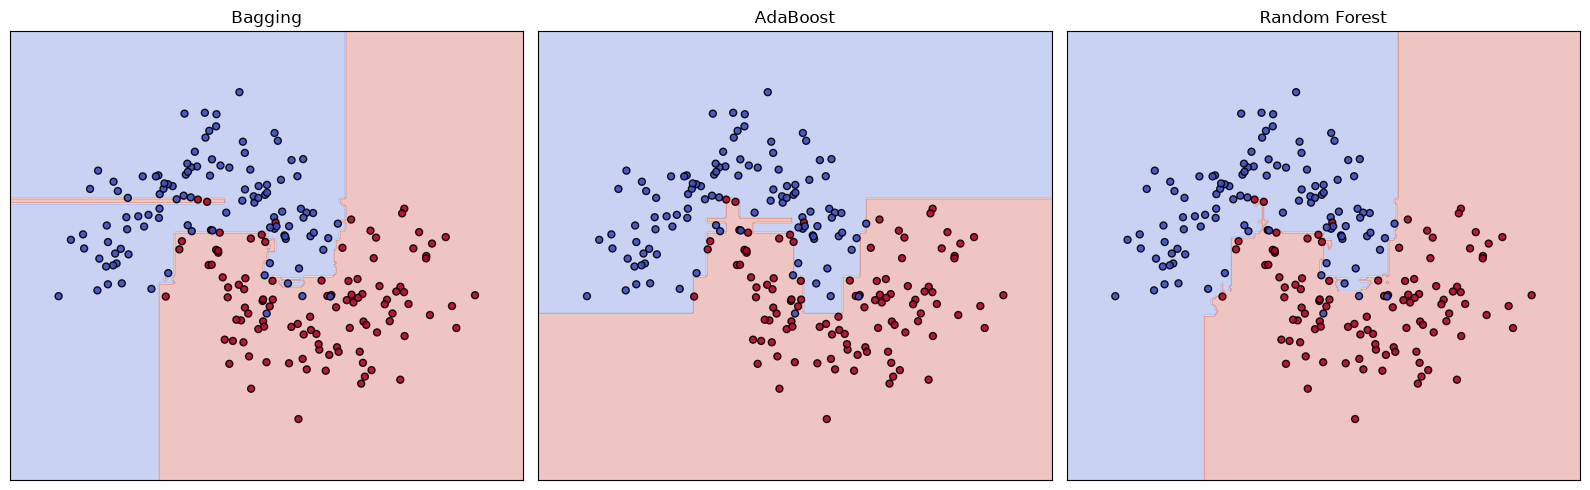

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_demo = RandomForestClassifier(n_estimators=100, random_state=42)
rf_demo.fit(X_syn_train, y_syn_train)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_decision_boundary(bagging_demo, X_syn_train, y_syn_train, axes[0], 'Bagging')
plot_decision_boundary(ada_demo, X_syn_train, y_syn_train, axes[1], 'AdaBoost')
plot_decision_boundary(rf_demo, X_syn_train, y_syn_train, axes[2], 'Random Forest')
plt.tight_layout()
plt.show()

As três fronteiras são qualitativamente parecidas nesse exemplo simples, mas cada uma chega lá por um caminho diferente: bagging suaviza uma árvore instável agregando cópias bootstrap; AdaBoost combina, ponderadamente, muitos modelos extremamente simples; Random Forest é como o bagging, mas com árvores adicionalmente decorrelacionadas pela aleatoriedade nos atributos.

Avaliação quantitativa com `GridSearchCV`:

In [20]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)
rf_gs.fit(X_art_train, y_art_train)

print('Melhores hiperparâmetros:', rf_gs.best_params_)
print('Melhor AUC (validação cruzada, treino):', rf_gs.best_score_)

Melhores hiperparâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Melhor AUC (validação cruzada, treino): 0.980651836484747


Acurácia (teste): 0.9233333333333333
AUC (teste): 0.9804444444444445


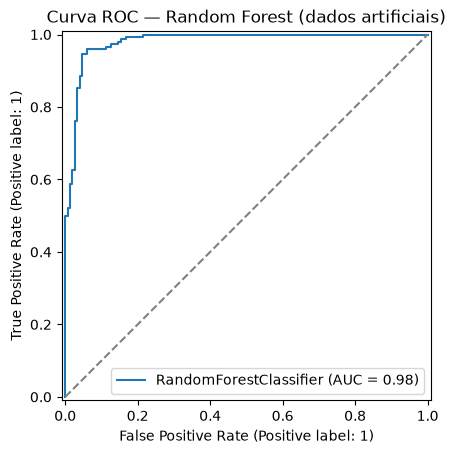

In [22]:
rf_best = rf_gs.best_estimator_
y_pred_rf = rf_best.predict(X_art_test)
y_score_rf = rf_best.predict_proba(X_art_test)[:, 1]

print('Acurácia (teste):', accuracy_score(y_art_test, y_pred_rf))
print('AUC (teste):', roc_auc_score(y_art_test, y_score_rf))

RocCurveDisplay.from_estimator(rf_best, X_art_test, y_art_test)
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('Curva ROC — Random Forest (dados artificiais)')
plt.show()

### Importância dos atributos

Como geramos os dados (`make_classification`), sabemos exatamente quais dos 20 atributos são realmente informativos (os 5 primeiros) e quais são puro ruído (os 15 seguintes). Isso nos dá uma oportunidade de conferir diretamente se a importância de atributos calculada pela Random Forest (`feature_importances_`, a Mean Decrease in Impurity, MDI) aponta corretamente para os atributos informativos.

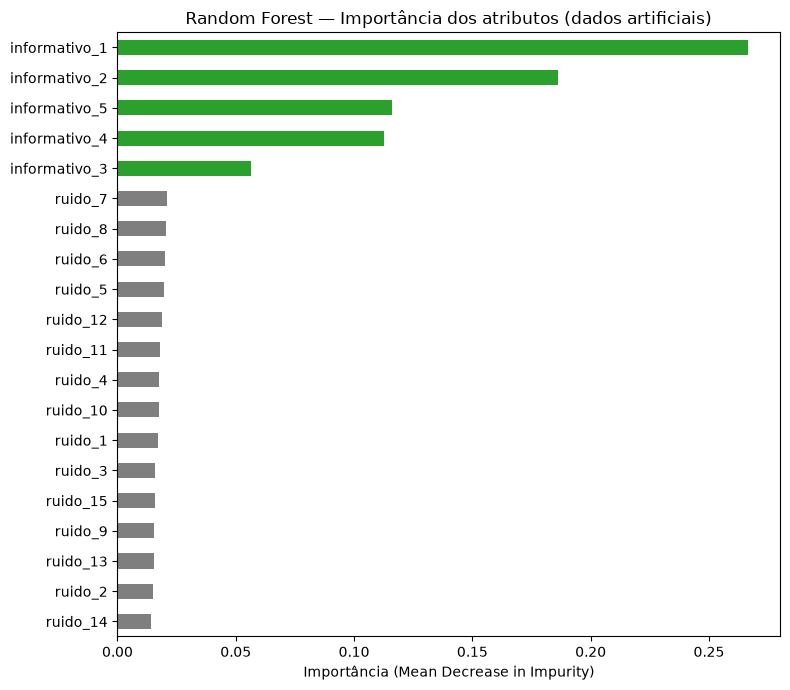

In [26]:
import pandas as pd

importancias_art = pd.Series(rf_best.feature_importances_, index=feature_names_art)
importancias_art = importancias_art.sort_values(ascending=False)

cores = ['tab:green' if 'informativo' in nome else 'tab:gray' for nome in importancias_art.index]

plt.figure(figsize=(8, 7))
importancias_art.plot(kind='barh', color=cores)
plt.gca().invert_yaxis()
plt.xlabel('Importância (Mean Decrease in Impurity)')
plt.title('Random Forest — Importância dos atributos (dados artificiais)')
plt.tight_layout()
plt.show()

Os atributos em verde são os que sabemos, por construção, serem realmente informativos; os em cinza são puro ruído. Se o método estiver funcionando como esperado, os atributos verdes devem concentrar a maior parte da importância, aparecendo no topo do gráfico. Uma confirmação direta (que não temos como fazer com dados reais, já que lá não sabemos a resposta certa de antemão) de que a importância de atributos da Random Forest está de fato capturando sinal, e não ruído.

### Comparação final (dados artificiais)

Vamos comparar esses classificadores.

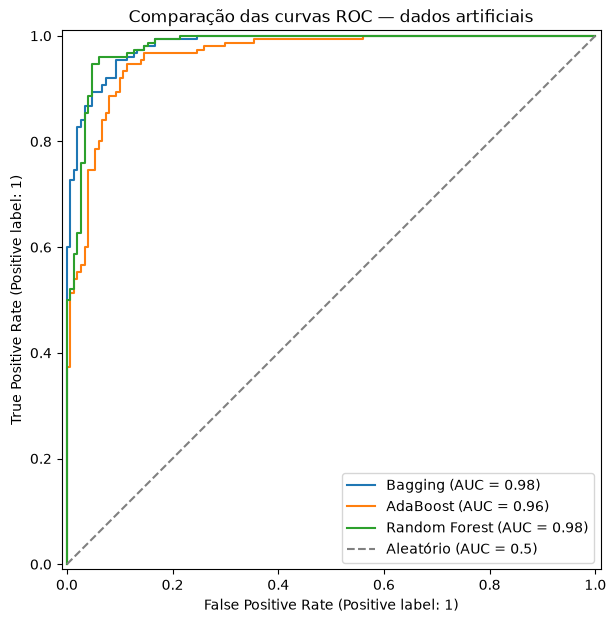

,Modelo,Acurácia (teste),AUC (teste)
0,Bagging,0.923333,0.982489
1,AdaBoost,0.910000,0.961289
2,Random Forest,0.923333,0.980444


In [28]:
fig, ax = plt.subplots(figsize=(7, 7))

RocCurveDisplay.from_estimator(bagging_best, X_art_test, y_art_test, ax=ax, name='Bagging')
RocCurveDisplay.from_estimator(ada_best, X_art_test, y_art_test, ax=ax, name='AdaBoost')
RocCurveDisplay.from_estimator(rf_best, X_art_test, y_art_test, ax=ax, name='Random Forest')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Aleatório (AUC = 0.5)')
ax.set_title('Comparação das curvas ROC — dados artificiais')
ax.legend()
plt.show()

resultados_art = pd.DataFrame({
    'Modelo': ['Bagging', 'AdaBoost', 'Random Forest'],
    'Acurácia (teste)': [
        accuracy_score(y_art_test, y_pred_bag),
        accuracy_score(y_art_test, y_pred_ada),
        accuracy_score(y_art_test, y_pred_rf),
    ],
    'AUC (teste)': [
        roc_auc_score(y_art_test, y_score_bag),
        roc_auc_score(y_art_test, y_score_ada),
        roc_auc_score(y_art_test, y_score_rf),
    ],
})
resultados_art

## 2 — Dados reais

Nesta parte, saímos do ambiente controlado dos dados artificiais e usamos um conjunto de dados real, lido a partir de um arquivo.

- Vamos considerar os dados da flor íris, que tem **3 classes** (não 2), então a curva ROC e a AUC precisam ser calculadas com a estratégia *one-vs-rest*;
- Vamos usar o mesmo arquivo para dois propósitos: um problema de **classificação** (prever a espécie a partir das medidas) e, na sequência, um problema de **regressão** (prever o comprimento da pétala a partir dos demais atributos).

In [30]:
import pandas as pd
import numpy as np

# Se for ler do Google Drive:
# Monta o Google Drive na pasta '/content/drive' deste ambiente do Colab.
# Depois deste comando, os arquivos do seu Drive ficam acessíveis normalmente,
# como se fossem arquivos locais dentro de '/content/drive/MyDrive/...'
#from google.colab import drive
#drive.mount('/content/drive/')
#caminho_drive = '/content/drive/MyDrive/data/iris.csv'
#data = pd.read_csv(caminho_drive, header=0)

# Descomente para ler do computador (offline)
# header=0 indica que a primeira linha contém os nomes das colunas.
data = pd.read_csv(r"C:\Users\saulosgil\OneDrive\Documentos\CursoMLeCD-USP\data\iris.csv", header=0)

print('Número de observações e atributos:', data.shape)
print('Classes:', data['species'].unique())
data.head(10)

Número de observações e atributos: (150, 5)
Classes: <ArrowStringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


### Classificação: prevendo a espécie

In [31]:
from sklearn.model_selection import train_test_split

feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = data[feature_cols].to_numpy()
y = data[data.columns[-1]].to_numpy()
classes = np.unique(y)

# treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, X, test_size=0.3, random_state=42, stratify=y
)

print('Treinamento:', X_train.shape, ' Teste:', X_test.shape)
print('Classes:', classes)

Treinamento: (105, 4)  Teste: (45, 4)
Classes: ['setosa' 'versicolor' 'virginica']


Como o Iris tem 3 classes, usamos a estratégia **one-vs-rest**: calculamos uma curva ROC (e uma AUC) para cada espécie contra as demais, e resumimos com a **AUC macro** (a média simples das 3 AUCs). O `GridSearchCV` também precisa de um `scoring` compatível com múltiplas classes. Usamos `'roc_auc_ovr'`, que já implementa essa mesma ideia internamente.

Vamos definir uma função auxiliar para calcular e desenhar as curvas ROC one-vs-rest, já que faremos isso três vezes (uma para cada método).

In [32]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


def plot_multiclass_roc(model, X_test, y_test, title):
    """
    Plota uma curva ROC para cada classe usando one-vs-rest
    e retorna a AUC macro.
    """
    # Usa a ordem de classes adotada pelo próprio modelo.
    classes = model.classes_

    # Converte as classes reais para o formato one-vs-rest.
    y_test_bin = label_binarize(y_test, classes=classes)

    # Probabilidades previstas para cada classe.
    y_proba = model.predict_proba(X_test)

    aucs = []

    plt.figure(figsize=(7, 7))

    # Calcula uma curva ROC para cada classe.
    for i, classe in enumerate(classes):
        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_proba[:, i]
        )

        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        plt.plot(
            fpr,
            tpr,
            label=f"{classe} vs. restante (AUC = {roc_auc:.3f})"
        )

    # Referência de um classificador aleatório.
    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        color="gray",
        label="Aleatório (AUC = 0,5)"
    )

    plt.xlabel("Taxa de falsos positivos (FPR)")
    plt.ylabel("Taxa de verdadeiros positivos (TPR)")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Média das AUCs das classes.
    macro_auc = np.mean(aucs)

    print(f"AUC macro one-vs-rest: {macro_auc:.4f}")

    return macro_auc

### Bagging

Melhores hiperparâmetros: {'estimator__max_depth': 2, 'max_samples': 0.5, 'n_estimators': 50}
Acurácia (teste): 0.9111111111111111


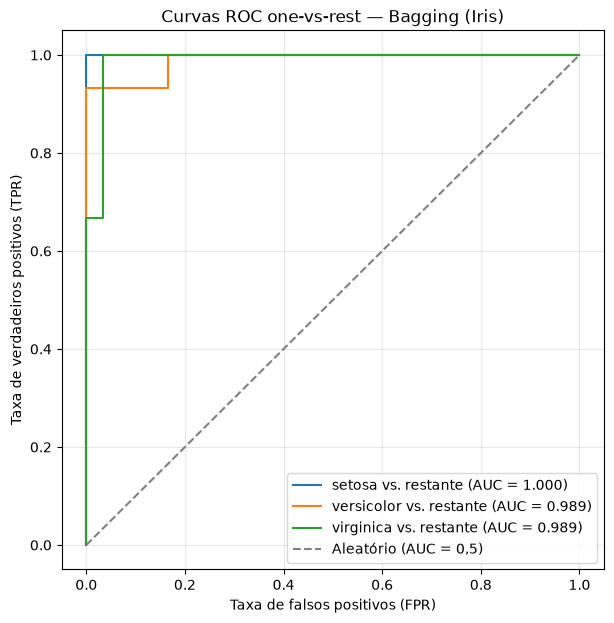

AUC macro one-vs-rest: 0.9926


In [34]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

param_grid_bag = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'estimator__max_depth': [2, 3, 5],
}

bagging_gs = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                      random_state=42),
    param_grid_bag,
    scoring='roc_auc_ovr',
    cv=5,
    n_jobs=-1,
)
bagging_gs.fit(X_train, y_train)
bagging_best = bagging_gs.best_estimator_

print('Melhores hiperparâmetros:', bagging_gs.best_params_)
print('Acurácia (teste):', accuracy_score(y_test, bagging_best.predict(X_test)))

auc_bag = plot_multiclass_roc(
    bagging_best,
    X_test,
    y_test,
    "Curvas ROC one-vs-rest — Bagging (Iris)"
)

### AdaBoost

Melhores hiperparâmetros: {'learning_rate': 0.1, 'n_estimators': 100}
Acurácia (teste): 0.9333333333333333


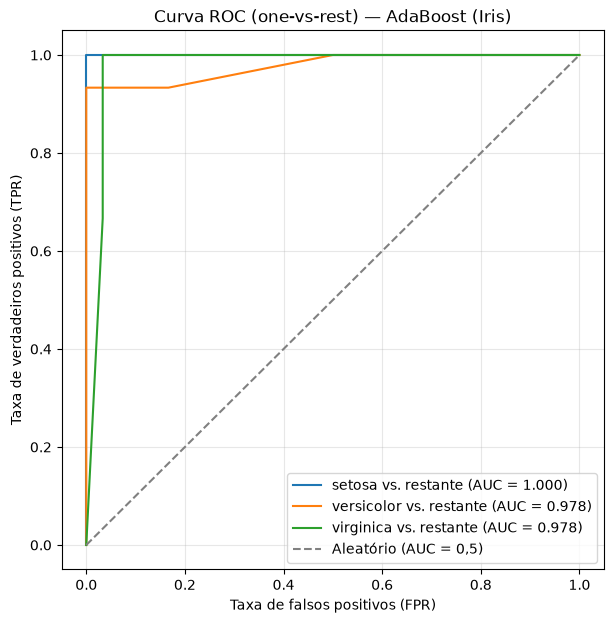

AUC macro one-vs-rest: 0.9852


In [35]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
}

ada_gs = GridSearchCV(
    AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), random_state=42),
    param_grid_ada,
    scoring='roc_auc_ovr',
    cv=5,
    n_jobs=-1,
)
ada_gs.fit(X_train, y_train)
ada_best = ada_gs.best_estimator_

print('Melhores hiperparâmetros:', ada_gs.best_params_)
print('Acurácia (teste):', accuracy_score(y_test, ada_best.predict(X_test)))

auc_ada = plot_multiclass_roc(
    ada_best,
    X_test,
    y_test,
    'Curva ROC (one-vs-rest) — AdaBoost (Iris)'
)


### Random Forest

Melhores hiperparâmetros: {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 200}
Acurácia (teste): 0.9111111111111111


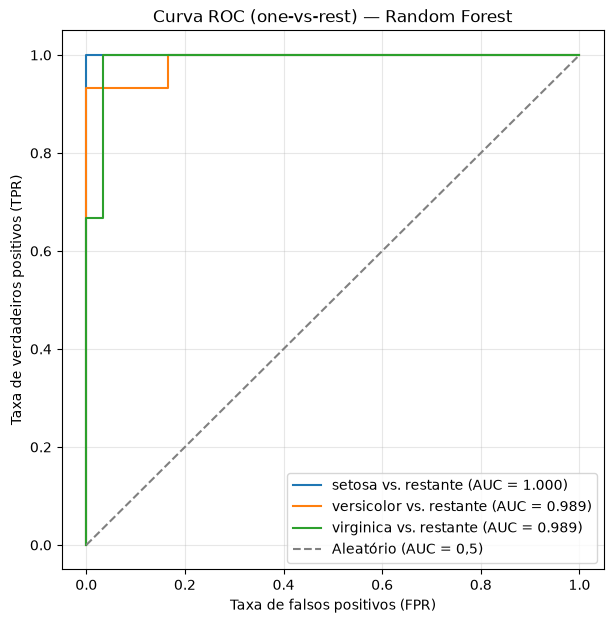

AUC macro one-vs-rest: 0.9926


In [36]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5],
    'max_features': ['sqrt', 'log2'],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='roc_auc_ovr',
    cv=5,
    n_jobs=-1,
)
rf_gs.fit(X_train, y_train)
rf_best = rf_gs.best_estimator_

print('Melhores hiperparâmetros:', rf_gs.best_params_)
print('Acurácia (teste):', accuracy_score(y_test, rf_best.predict(X_test)))

auc_rf = plot_multiclass_roc(
    rf_best,
    X_test,
    y_test,
    'Curva ROC (one-vs-rest) — Random Forest'
)

### Importância dos atributos (Iris)

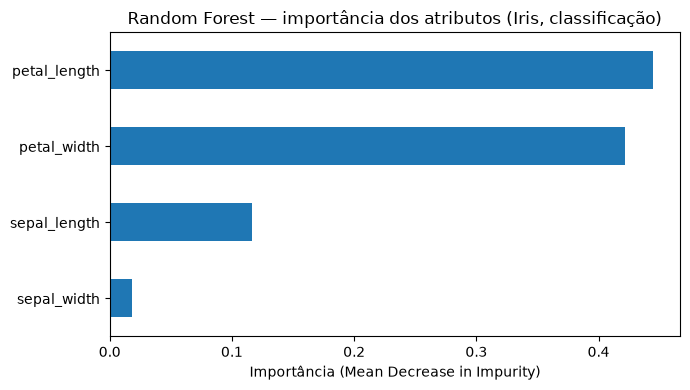

In [37]:
importancias = pd.Series(rf_best.feature_importances_, index=feature_cols)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importancias.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importância (Mean Decrease in Impurity)')
plt.title('Random Forest — importância dos atributos (Iris, classificação)')
plt.tight_layout()
plt.show()

É um resultado bem conhecido sobre o conjunto de Iris que as medidas da **pétala** (comprimento e largura) são muito mais discriminativas entre as três espécies do que as medidas da sépala — e é exatamente isso que esperamos ver refletido na importância de atributos calculada pela Random Forest.

### Comparação final (Iris, classificação)

In [38]:
resultados = pd.DataFrame({
    'Modelo': ['Bagging', 'AdaBoost', 'Random Forest'],
    'Acurácia (teste)': [
        accuracy_score(y_test, bagging_best.predict(X_test)),
        accuracy_score(y_test, ada_best.predict(X_test)),
        accuracy_score(y_test, rf_best.predict(X_test)),
    ],
    'AUC macro (teste)': [auc_bag, auc_ada, auc_rf],
})
resultados


,Modelo,Acurácia (teste),AUC macro (teste)
0,Bagging,0.911111,0.992593
1,AdaBoost,0.933333,0.985185
2,Random Forest,0.911111,0.992593


A classificação da flor íris é um problema relativamente fácil (as espécies são bem separáveis a partir dessas 4 medidas), então é comum observar os três métodos com desempenho muito parecido e próximo do teto (acurácia e AUC altas) — diferente do que vimos com o AdaBoost em relação à árvore única na Parte 1, onde a diferença tende a ser mais visível em problemas mais difíceis.

## Regressão: prevendo o comprimento da pétala

Para o exemplo de regressão, vamos usar o **mesmo arquivo** `iris.csv`, mas trocando o que consideramos "atributo" e "alvo": em vez de prever a espécie (categórica) a partir das 4 medidas, vamos prever o **comprimento da pétala** (`petal_length`, uma variável contínua) a partir da largura da pétala, das medidas da sépala, e da espécie (usada aqui como um atributo categórico, convertido em variáveis indicadoras/*dummy*).

In [39]:
# variável alvo (regressão): comprimento da pétala
y_reg = data['petal_length'].to_numpy()

# atributos: as demais medidas numéricas + a espécie, codificada como variáveis indicadoras
X_reg_df = data[['sepal_length', 'sepal_width', 'petal_width']].copy()
especies_dummies = pd.get_dummies(data[data.columns[-1]], prefix='species', drop_first=True)
X_reg_df = pd.concat([X_reg_df, especies_dummies], axis=1)

feature_names_reg = X_reg_df.columns.tolist()
X_reg = X_reg_df.to_numpy()

print('Atributos usados na regressão:', feature_names_reg)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

Atributos usados na regressão: ['sepal_length', 'sepal_width', 'petal_width', 'species_versicolor', 'species_virginica']


In [41]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf_reg = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 3, 5, 10],
    'max_features': [1.0, 'sqrt', 'log2'],
}

rf_reg_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf_reg,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
)
rf_reg_gs.fit(X_reg_train, y_reg_train)
rf_reg_best = rf_reg_gs.best_estimator_

print('Melhores hiperparâmetros:', rf_reg_gs.best_params_)

Melhores hiperparâmetros: {'max_depth': 5, 'max_features': 1.0, 'n_estimators': 200}


RMSE (teste): 0.2731705131308413
R2 (teste): 0.9778699387956172


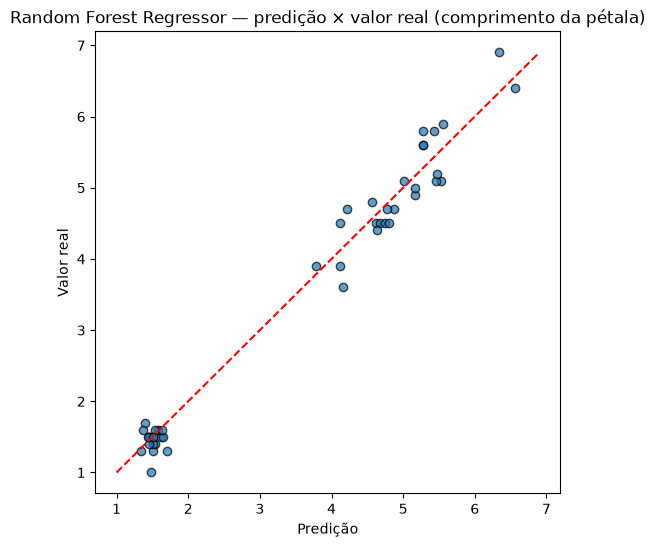

In [42]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_reg = rf_reg_best.predict(X_reg_test)

RMSE = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
R2 = r2_score(y_reg_test, y_pred_reg)
print('RMSE (teste):', RMSE)
print('R2 (teste):', R2)

plt.figure(figsize=(6, 6))
plt.scatter(y_pred_reg, y_reg_test, alpha=0.7, edgecolor='k')
lims = [min(y_reg_test.min(), y_pred_reg.min()), max(y_reg_test.max(), y_pred_reg.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Predição')
plt.ylabel('Valor real')
plt.title('Random Forest Regressor — predição × valor real (comprimento da pétala)')
plt.show()

### Importância dos atributos (regressão)

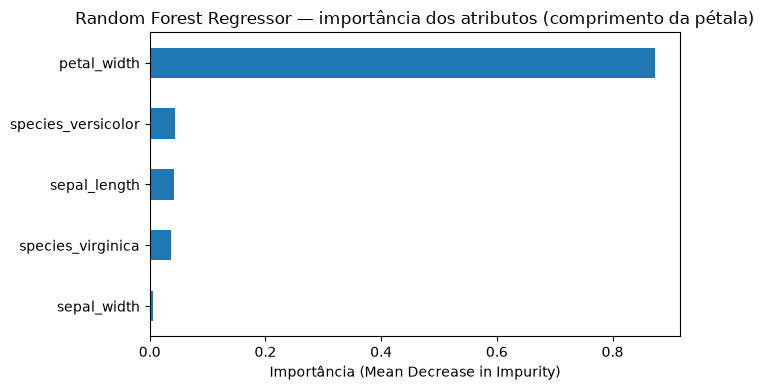

In [43]:
importancias_reg = pd.Series(rf_reg_best.feature_importances_, index=feature_names_reg)
importancias_reg = importancias_reg.sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importancias_reg.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Importância (Mean Decrease in Impurity)')
plt.title('Random Forest Regressor — importância dos atributos (comprimento da pétala)')
plt.tight_layout()
plt.show()

Faz sentido que a largura da pétala (`petal_width`) e as variáveis indicadoras de espécie apareçam entre os atributos mais importantes: pétala larga e comprida tendem a andar juntas, e espécies diferentes têm pétalas de tamanhos característicos bem distintos. O mesmo padrão que já havíamos visto na classificação, agora sob a perspectiva de um problema de regressão.

### Resumo: Bagging × Boosting (AdaBoost) × Random Forest

| | Bagging | AdaBoost (Boosting) | Random Forest |
|---|---|---|---|
| Treinamento dos modelos base | Paralelo, independente | Sequencial, cada modelo depende do anterior | Paralelo, independente (como o bagging) |
| Fonte de diversidade entre modelos | Amostragem bootstrap das observações | Reponderação das observações (foco nos erros) | Amostragem bootstrap **+** subconjunto aleatório de atributos em cada divisão |
| Ataca principalmente | Variância | Viés | Variância (de forma mais eficaz que o bagging simples) |
| Modelo base típico | Árvores profundas (alta variância, baixo viés) | Árvores rasas / *stumps* (alto viés, baixa variância) | Árvores profundas |
| Sensibilidade a outliers/ruído | Baixa (a agregação suaviza) | Alta (observações mal classificadas ganham mais peso a cada iteração) | Baixa |
| Paralelizável | Sim | Não (é inerentemente sequencial) | Sim |

Na prática, a Random Forest costuma ser uma excelente escolha "padrão" para muitos problemas — robusta, fácil de ajustar e com boa performance fora da caixa. O AdaBoost (e variantes modernas de boosting, como Gradient Boosting e XGBoost, fora do escopo desta aula) costuma alcançar desempenho ainda melhor quando bem ajustado, ao custo de ser mais sensível a hiperparâmetros e a ruído.

## Exercícios de fixação

1 - Na Parte 1 (dados artificiais), aumente o número de atributos de ruído em `make_classification` de 15 para, por exemplo, 100 (mantendo os 5 atributos informativos). Refaça o treinamento da Random Forest e observe o gráfico de importância de atributos: os 5 atributos informativos continuam sendo corretamente identificados como os mais importantes, mesmo cercados por muito mais ruído? O que isso sugere sobre a robustez do método a atributos irrelevantes?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split

# dados 2D, para visualização da fronteira de decisão
X_syn, y_syn = make_moons(n_samples=300, noise=0.25, random_state=42)
X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42, stratify=y_syn
)

# 5 atributos realmente informativos + 100 atributos que são apenas ruído
n_informativos = 5
n_ruido = 100

X_art, y_art = make_classification(
    n_samples=1000,
    n_features=n_informativos + n_ruido,
    n_informative=n_informativos,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=2,
    flip_y=0.02, # um pouco de ruído nos rótulos, para não ficar trivial demais
    class_sep=1.2,
    shuffle=False, # mantém a ordem das colunas: as n_informativos primeiras são as informativas
    random_state=42,
)
feature_names_art = [f'informativo_{i+1}' for i in range(n_informativos)] + \
                    [f'ruido_{i+1}' for i in range(n_ruido)]

X_art_train, X_art_test, y_art_train, y_art_test = train_test_split(X_art, y_art,
                                                                    test_size=0.3,
                                                                    random_state=42,
                                                                    stratify=y_art)

print('Número de observações e atributos:', X_art.shape)
print('Atributos realmente informativos:', feature_names_art[:n_informativos])


Número de observações e atributos: (1000, 105)
Atributos realmente informativos: ['informativo_1', 'informativo_2', 'informativo_3', 'informativo_4', 'informativo_5']


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# grid dos hiperparametros
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
)
rf_gs.fit(X_art_train, y_art_train)

print('Melhores hiperparâmetros:', rf_gs.best_params_)
print('Melhor AUC (validação cruzada, treino):', rf_gs.best_score_)

Melhores hiperparâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 300}
Melhor AUC (validação cruzada, treino): 0.9688554182236274


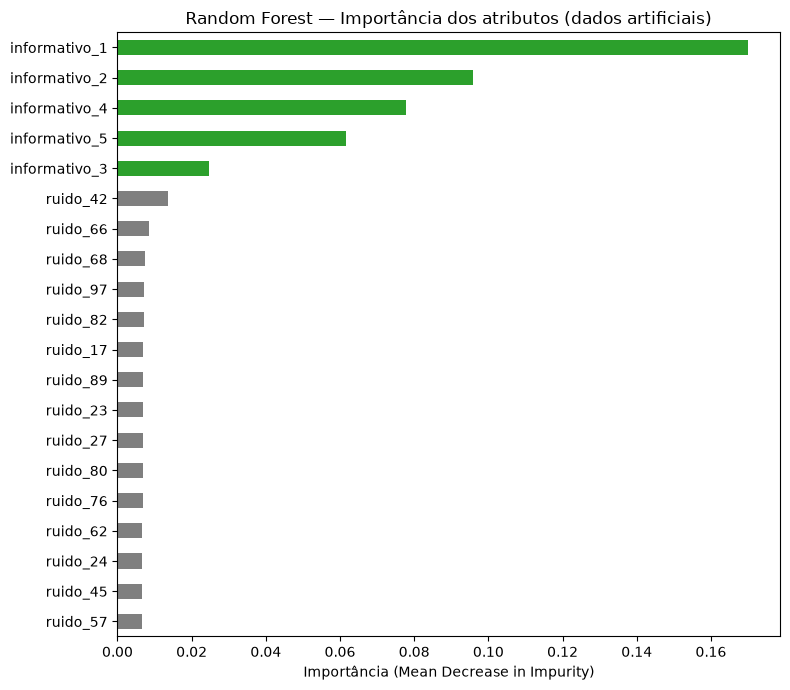

In [5]:
import pandas as pd

# importancia dos atributos
importancias_rf = pd.Series(rf_gs.best_estimator_.feature_importances_, index=feature_names_art)    
importancias_rf = importancias_rf.sort_values(ascending=False).head(20)

cores = ['tab:green' if 'informativo' in nome else 'tab:gray' for nome in importancias_rf.index]

plt.figure(figsize=(8, 7))
importancias_rf.plot(kind='barh', color=cores)
plt.gca().invert_yaxis()
plt.xlabel('Importância (Mean Decrease in Impurity)')
plt.title('Random Forest — Importância dos atributos (dados artificiais)')
plt.tight_layout()
plt.show()

Mesmo após a inclusão dos atributos ruidosos, os cinco atributos mais importantes permaneceram os mesmos e concentraram a maior parte da importância, resultado consistente com a conhecida robustez do Random Forest a variáveis irrelevantes.

### Feature Importance usando o `Permutation Feature Importance` (Mais indicado!)

O `Permitation Feature Importance` avalia a relevância de cada atributo medindo o quanto o desempenho do modelo piora quando os valores daquele atributo são embaralhados aleatoriamente. A lógica é direta: se uma variável é importante para as predições, destruir a relação entre ela e o alvo (mantendo sua distribuição, mas quebrando a associação) deve degradar a performance; se a variável é irrelevante, embaralhá-la não terá efeito. A queda média na métrica, calculada ao longo de várias repetições, é usada como medida de importância.

Diferentemente da importância por Mean Decrease in Impurity (MDI), calculada internamente durante a construção das árvores, a importância por permutação é obtida a partir das predições sobre um conjunto de dados — preferencialmente o conjunto de teste, o que reflete a contribuição de cada atributo para a capacidade de generalização do modelo, e não apenas para o ajuste aos dados de treino.

Essa abordagem é considerada a mais indicada por dois motivos principais. Primeiro, o MDI apresenta viés conhecido, superestimando a importância de variáveis contínuas e de alta cardinalidade — inclusive atributos ruidosos que, por acaso, assumam muitos valores distintos. Segundo, por ser calculada sobre o desempenho preditivo, a importância por permutação é agnóstica ao modelo (aplicável a qualquer estimador) e fornece também uma estimativa de incerteza (desvio-padrão entre as repetições), permitindo distinguir atributos genuinamente relevantes daqueles cuja importância é indistinguível de zero.

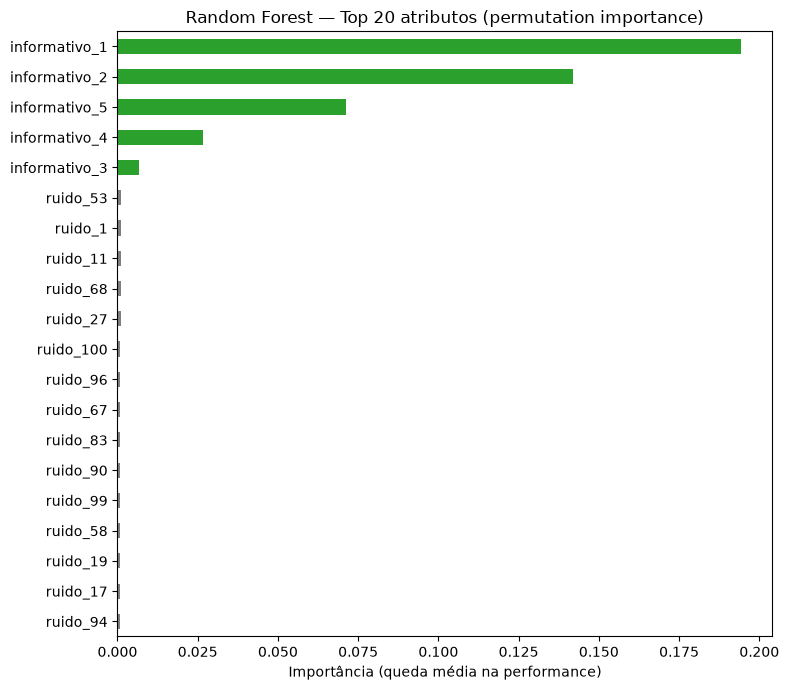

In [6]:
from sklearn.inspection import permutation_importance

# roda a permutação no conjunto de TESTE (mais honesto que no treino)
perm = permutation_importance(
    rf_gs.best_estimator_,
    X_art_test, y_art_test,
    n_repeats=30,
    random_state=42,
    scoring='roc_auc',   # escolha a métrica coerente com seu problema (binário desbalanceado)
    n_jobs=-1
)

# monta a série com média das quedas de performance
importancias_perm = pd.Series(perm.importances_mean, index=feature_names_art)
importancias_perm = importancias_perm.sort_values(ascending=False).head(20)

cores = ['tab:green' if 'informativo' in nome else 'tab:gray' for nome in importancias_perm.index]

plt.figure(figsize=(8, 7))
importancias_perm.plot(kind='barh', color=cores)
plt.gca().invert_yaxis()
plt.xlabel('Importância (queda média na performance)')
plt.title('Random Forest — Top 20 atributos (permutation importance)')
plt.tight_layout()
plt.show()

Mesmo utilizando o permutation importance os atributos permaneceram o mesmo.

2 - No exemplo do AdaBoost nos dados 2D (`make_moons`), varie o número de estimadores (`n_estimators`) entre 1, 5, 20 e 100, e observe como a fronteira de decisão evolui. A partir de que ponto aumentar `n_estimators` deixa de trazer mudanças visíveis?

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split

# dados 2D, para visualização da fronteira de decisão
X_syn, y_syn = make_moons(n_samples=300, noise=0.25, random_state=42)
X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42, stratify=y_syn
)

# 5 atributos realmente informativos + 100 atributos que são apenas ruído
n_informativos = 5
n_ruido = 100

X_art, y_art = make_classification(
    n_samples=1000,
    n_features=n_informativos + n_ruido,
    n_informative=n_informativos,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=2,
    flip_y=0.02, # um pouco de ruído nos rótulos, para não ficar trivial demais
    class_sep=1.2,
    shuffle=False, # mantém a ordem das colunas: as n_informativos primeiras são as informativas
    random_state=42,
)
feature_names_art = [f'informativo_{i+1}' for i in range(n_informativos)] + \
                    [f'ruido_{i+1}' for i in range(n_ruido)]

X_art_train, X_art_test, y_art_train, y_art_test = train_test_split(X_art, y_art,
                                                                    test_size=0.3,
                                                                    random_state=42,
                                                                    stratify=y_art)

print('Número de observações e atributos:', X_art.shape)
print('Atributos realmente informativos:', feature_names_art[:n_informativos])

Número de observações e atributos: (1000, 105)
Atributos realmente informativos: ['informativo_1', 'informativo_2', 'informativo_3', 'informativo_4', 'informativo_5']


In [23]:
# função para plotar a fronteira de decisão
def plot_decision_boundary(model, X, y, ax, title):
    """Desenha a fronteira de decisão de um classificador binário já
    treinado, sobre um grid 2D, junto com os pontos de treinamento.
    """
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=25, edgecolor='k', alpha=0.9)
    ax.set_title(title)
    ax.set_xticks(())
    ax.set_yticks(())

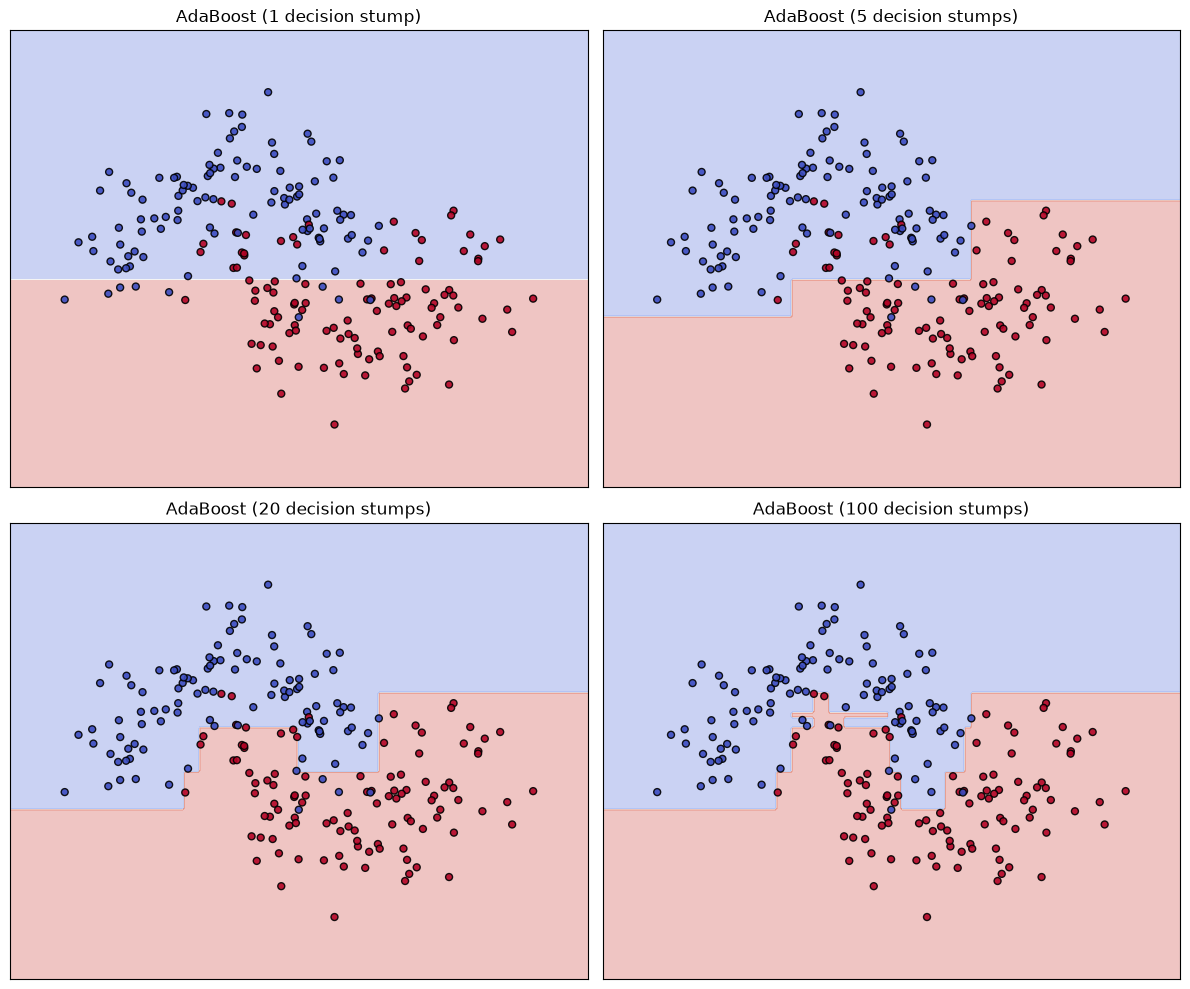

In [24]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()   # vira [ax00, ax01, ax10, ax11]

# Ada Boost - 1, 5, 20 e 100 estimadores (decision stump)
modelos = {}
n_estimadores = [1, 5, 20, 100]

for ax, n_estimadores in zip(axes, n_estimadores):
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n_estimadores,
        learning_rate=1.0,
        random_state=42,
    )
    ada.fit(X_syn_train, y_syn_train)
    modelos[n_estimadores] = ada

    rotulo = 'stump' if n_estimadores == 1 else 'stumps'
    
    plot_decision_boundary(ada, X_syn_train, y_syn_train, ax,
                           f'AdaBoost ({n_estimadores} decision {rotulo})')

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import accuracy_score

for n, m in modelos.items():
    tr = accuracy_score(y_syn_train, m.predict(X_syn_train))
    te = accuracy_score(y_syn_test, m.predict(X_syn_test))
    print(f"{n:>3} estimadores | treino {tr:.3f} | teste {te:.3f}")

  1 estimadores | treino 0.824 | teste 0.778
  5 estimadores | treino 0.905 | teste 0.878
 20 estimadores | treino 0.957 | teste 0.889
100 estimadores | treino 0.981 | teste 0.933


A partir de 20 estimadores, o aumento para 100 não traz benefício: a acurácia de treino sobe de X para Y, enquanto a de teste permanece em Z (ou cai), indicando que os estimadores adicionais passam a ajustar ruído em vez de estrutura. Visualmente, isso aparece como uma fronteira progressivamente mais recortada em torno de pontos isolados.

3 - Faça a classificação da base de veículos usando o random forest.